# M5: GRU

Ova sveska trenira i ocenjuje M5 GRU nad sekvencama prethodno odigranih mečeva.

Svaka rekurentna mreža ima svoju svesku, da bi se moglo raditi paralelno. Sve
tri dele istu arhitekturu (`models.MatchPredictor`) i istu petlju treniranja
(`train.train_model`), ali je svaka podešena nezavisno — razlikuje se parametar
`cell`, a hiperparametri se biraju posebno po mreži.

Izbor hiperparametara ide u dva koraka, a izabrana postavka se trenira sa pet
seedova iz `config.SEEDS`, jer su početne težine i redosled paketića slučajni
pa jedan seed ume prividno da izdvoji jednu mrežu. Prijavljena metrika je
prosek po seedovima. Potpuno izvršavanje istrenira oko osamdeset mreža i traje
desetak do petnaest minuta.

Skup podataka se može preuzeti sa [ove](https://www.kaggle.com/datasets/nathanlauga/nba-games) adrese.

## Priprema

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd

import torch
from torch.utils.data import DataLoader

from src.config import (BATCH_SIZE, MODELS_PATH, PROCESSED_DATA_PATH, RANDOM_STATE,
                        RESULTS_FILE, SEEDS)
from src import evaluate, models, plotting, sequences, train

train.set_seed(RANDOM_STATE)

## Učitavanje sekvenci

Iste `sekvence.npz` i iste `train`/`validation` pozicije kao u svesci 02/03 — isti mečevi kao za M0-M4, kako bi poređenje bilo pošteno. 

In [2]:
splits = np.load(PROCESSED_DATA_PATH / "sekvence.npz")
home_sequences, away_sequences = splits["home_sequences"], splits["away_sequences"]
context, labels = splits["context"], splits["labels"]
train_idx, validation_idx = splits["train"], splits["validation"]

home_train, away_train = home_sequences[train_idx], away_sequences[train_idx]
context_train, y_train = context[train_idx], labels[train_idx]

home_val, away_val = home_sequences[validation_idx], away_sequences[validation_idx]
context_val, y_val = context[validation_idx], labels[validation_idx]

home_train.shape, context_train.shape

((18092, 10, 8), (18092, 24))

## Dataset i DataLoader

`shuffle=True` meša samo redosled kojim mreža vidi već-fiksirane trening mečeve unutar jedne epohe — ne dira podelu na skupove, koja je hronološka i fiksirana još u svesci 02. Validacija se ne meša, jer se na njoj ne trenira.

In [3]:
dataset_train = sequences.MatchSequenceDataset(home_train, away_train, context_train, y_train)
dataset_val = sequences.MatchSequenceDataset(home_val, away_val, context_val, y_val)

loader_train = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True)
loader_val = DataLoader(dataset_val, batch_size=BATCH_SIZE, shuffle=False)

len(dataset_train), len(dataset_val)

(18092, 2624)

## Izbor hiperparametara

Hiperparametri se biraju pre treniranja, jer sve što sledi zavisi od njih. Pretraga ide u dva koraka.

Prvo gruba pretraga po celoj mreži vrednosti iz `config.py` (`HIDDEN_SIZE_GRID`, `DROPOUT_GRID`, `LEARNING_RATE_GRID`), sa jednim seedom po kombinaciji. Zatim se prvih `N_FINALISTS` kandidata trenira ponovo, sa svih pet seedova, i pobednik se bira po proseku.

Drugi korak postoji zato što jedno merenje po kombinaciji nije dovoljno da ih razdvoji — razlike u vrhu tabele su reda veličine rasipanja po seedovima. Mreža vrednosti i broj finalista stoje u `config.py`, isti za sve tri rekurentne mreže.

**Prvi korak — gruba pretraga.** Jedan seed po kombinaciji, poredak po `roc_auc` na validaciji.

In [4]:
rezultati_pretrage = train.search_hyperparameters(
    loader_train, loader_val,
    n_features=home_train.shape[-1],
    n_context=context_train.shape[-1],
    cell="gru",
)

rezultati_pretrage.head(5).round(4)

,hidden_size,dropout,learning_rate,tacnost,roc_auc,log_loss,brier
0,64,0.30,0.003,0.6551,0.6983,0.6180,0.2143
1,64,0.15,0.003,0.6532,0.6974,0.6186,0.2145
2,32,0.30,0.003,0.6562,0.6969,0.6180,0.2144
3,64,0.00,0.003,0.6547,0.6968,0.6186,0.2146
4,32,0.15,0.003,0.6582,0.6968,0.6180,0.2143


**Drugi korak.** Svaki finalista se trenira pet puta, pa se poredi prosek. Kolona `rasipanje` pokazuje koliko se ishod menja od pokretanja do pokretanja.

In [5]:
finalisti = train.refine_hyperparameters(
    rezultati_pretrage, dataset_train, dataset_val,
    n_features=home_train.shape[-1],
    n_context=context_train.shape[-1],
    cell="gru",
)

finalisti.round(4)

,hidden_size,dropout,learning_rate,tacnost,rasipanje,roc_auc,roc_auc_rasipanje
0,32,0.30,0.003,0.6579,0.0022,0.6975,0.0013
1,32,0.15,0.003,0.6560,0.0021,0.6972,0.0016
2,64,0.30,0.003,0.6552,0.0007,0.6971,0.0004
3,64,0.15,0.003,0.6560,0.0022,0.6970,0.0010
4,64,0.00,0.003,0.6566,0.0023,0.6968,0.0008


In [6]:
najbolji = finalisti.iloc[0]

print(f"hidden_size   {int(najbolji['hidden_size'])}")
print(f"dropout       {najbolji['dropout']}")
print(f"learning_rate {najbolji['learning_rate']}")
print(f"roc_auc       {najbolji['roc_auc']:.4f} +- {najbolji['roc_auc_rasipanje']:.4f}")
print(f"tacnost       {najbolji['tacnost']:.4f} +- {najbolji['rasipanje']:.4f}")

hidden_size   32
dropout       0.3
learning_rate 0.003
roc_auc       0.6975 +- 0.0013
tacnost       0.6579 +- 0.0022


Drugi korak ovde ne samo potvrđuje pobednika grube pretrage nego menja poredak: `hidden_size=64, dropout=0.30` je bio prvi sa jednim seedom (ROC-AUC 0.6983), ali sa pet seedova pada na treće mesto (0.6971). Na prvo mesto dolazi `hidden_size=32, dropout=0.30`, treće u gruboj pretrazi (0.6969 sa jednim seedom). Ovo je direktan dokaz zašto je drugi korak potreban - jedno merenje po kombinaciji je bilo dovoljno da izabere pogrešnog kandidata.

Izbor ipak nije oštar ni posle drugog koraka: svih pet finalista staje u raspon od 0.0007 ROC-AUC (0.6968-0.6975), uže od pojedinačnog rasipanja po seedovima kod većine njih (do 0.0023). Prva dva mesta dele isti `dropout` i istu stopu učenja, razlikuju se samo po `hidden_size` (32 naspram 64) i po 0.0003 ROC-AUC.

Izabrana stopa učenja `0.003` je najveća u mreži iz `config.py`. Pošto je pobednik pao na samu granicu, na kraju sveske proveravamo šta leži izvan nje.

## Kreiranje mreže

`cell="gru"` daje M5 GRU.

`MatchPredictor` obrađuje sekvencu domaćina i sekvencu gosta **istom** ćelijom (deljene težine), uzima poslednje skriveno stanje svake kao naučeni sažetak forme, nalepi ih uz kontekst i propusti kroz jedan linearni sloj do sirovog logita.

In [7]:
train.set_seed(RANDOM_STATE)

model_gru = models.MatchPredictor(
    n_features=home_train.shape[-1],
    n_context=context_train.shape[-1],
    cell="gru",
    hidden_size=int(najbolji["hidden_size"]),
    dropout=float(najbolji["dropout"]),
)
model_gru

MatchPredictor(
  (encoder): GRU(8, 32, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (output): Linear(in_features=88, out_features=1, bias=True)
)

## Treniranje mreže

Ista postavka se trenira pet puta, po jednom za svaki seed iz `config.SEEDS`,
jer su početne težine i redosled paketića slučajni.

Prijavljena metrika je prosek po seedovima. Grafici i matrica konfuzije se
crtaju za jedan model, pa za njih služi prolaz sa seedom `RANDOM_STATE`.

In [8]:
prolazi = train.train_over_seeds(
    dataset_train, dataset_val,
    n_features=home_train.shape[-1],
    n_context=context_train.shape[-1],
    cell="gru",
    hidden_size=int(najbolji["hidden_size"]),
    dropout=float(najbolji["dropout"]),
    learning_rate=float(najbolji["learning_rate"]),
)

# reprezentativni prolaz - onaj sa seedom iz config.py; sluzi za grafike,
# matricu konfuzije i kalibraciju, koje se crtaju za jedan model
model_gru = next(p["model"] for p in prolazi if p["seed"] == RANDOM_STATE)
history = next(p["history"] for p in prolazi if p["seed"] == RANDOM_STATE)

pd.DataFrame([{
    "seed": p["seed"],
    "epoha": len(p["history"]["train_loss"]),
    "najbolja": int(np.argmin(p["history"]["valid_loss"])) + 1,
    **p["metrike"],
} for p in prolazi]).round(4)

,seed,epoha,najbolja,tacnost,roc_auc,log_loss,brier
0,7,14,9,0.6601,0.6985,0.6164,0.2139
1,17,12,7,0.6562,0.6979,0.6167,0.2139
2,27,10,5,0.6608,0.6953,0.6192,0.2149
3,37,11,6,0.6555,0.6990,0.6163,0.2137
4,47,8,3,0.6566,0.6969,0.6181,0.2144


## Krive učenja

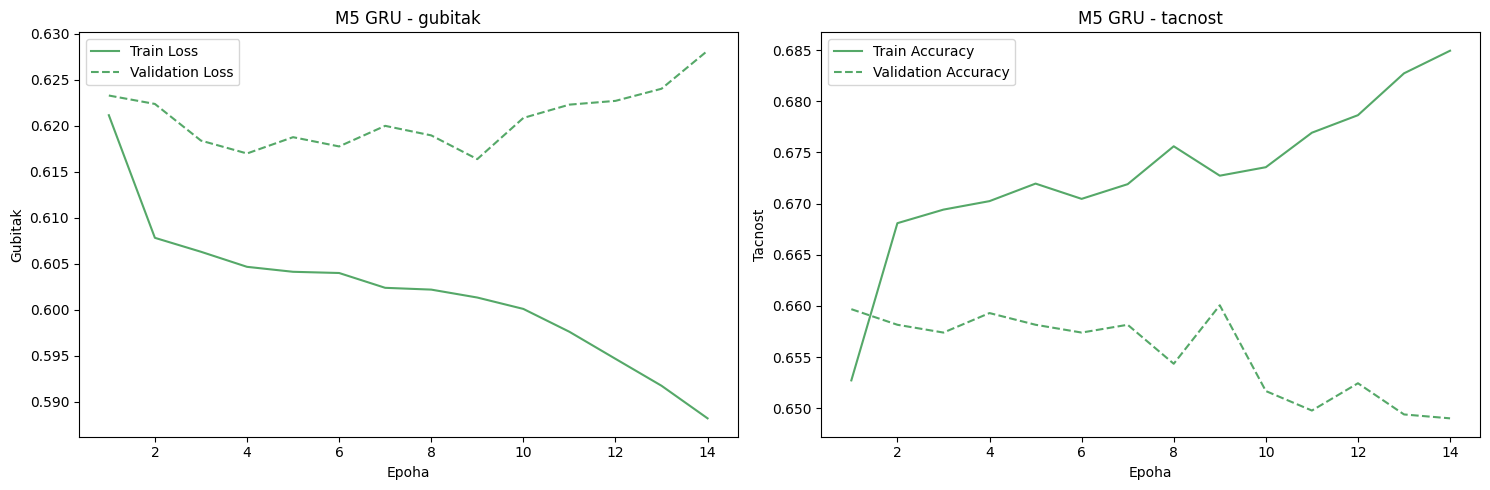

najbolja epoha: 9 od 14
validacioni gubitak: prva epoha 0.6233, najbolja 0.6164, poslednja 0.6281
razmak trening-validacija: 0.002 -> 0.040
validaciona tacnost: od 0.6490 do 0.6601


In [9]:
plotting.plot_learning_curves(history, "M5 GRU")

najbolja = int(np.argmin(history["valid_loss"]))
print(f"najbolja epoha: {najbolja + 1} od {len(history['valid_loss'])}")
print(f"validacioni gubitak: prva epoha {history['valid_loss'][0]:.4f},"
      f" najbolja {history['valid_loss'][najbolja]:.4f},"
      f" poslednja {history['valid_loss'][-1]:.4f}")
print(f"razmak trening-validacija: {history['valid_loss'][0] - history['train_loss'][0]:.3f}"
      f" -> {history['valid_loss'][-1] - history['train_loss'][-1]:.3f}")
print(f"validaciona tacnost: od {min(history['valid_accuracy']):.4f}"
      f" do {max(history['valid_accuracy']):.4f}")

Prikazan je prolaz sa seedom `RANDOM_STATE` (7). Levi grafik pokazuje gubitak: trening opada kroz sve epohe, a validacija dostiže minimum u 9. epohi (0.6164), pa rano zaustavljanje preseca trening u 14. Razmak između krivih raste sa 0.002 na 0.040 - jasnije preprilagođavanje nego kod M3, koje rano zaustavljanje ipak hvata na vreme.

Desni grafik pokazuje tačnost bez jasnog trenda: osciluje između 0.6490 i 0.6601, raspon od 1.1 procentnog poena kod jednog istog modela, samo kroz epohe. Po tabeli iznad, najbolja epoha se među seedovima kreće od 3 do 9 - još jedan razlog zašto se prijavljuje prosek po seedovima, a ne jedan prolaz.

## Evaluacija modela

Matrica konfuzije i kalibracija na validaciji; zbirne metrike idu u `reports/rezultati.csv` kao prosek po seedovima, a pojedinačni prolazi u `reports/rasipanje-semena.csv`. Test skup se ovde ne dodiruje.

In [10]:
loader_train_eval = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=False)

for skup, loader in [("trening", loader_train_eval), ("validacija", loader_val)]:
    po_seedu = []

    for prolaz in prolazi:
        y_proba, y_true = train.predict_proba(prolaz["model"], loader)
        metrike = evaluate.compute_metrics(y_true, y_proba)
        evaluate.append_seed_results("M5 GRU", skup, prolaz["seed"], metrike)
        po_seedu.append(metrike)

    prosek = {kljuc: float(np.mean([m[kljuc] for m in po_seedu])) for kljuc in po_seedu[0]}
    evaluate.append_results("M5 GRU", skup, prosek)

# test redovi se ovde ne prikazuju: ova sveska ih ne racuna i ne sme da
# ih otkrije, jer se test otvara tek u svesci 05
pd.read_csv(RESULTS_FILE).query("skup != 'test'").reset_index(drop=True)

,model,skup,tacnost,roc_auc,log_loss,brier
0,M0 domacin,trening,0.599547,0.500000,0.673195,0.240090
1,M0 domacin,validacija,0.588796,0.500000,0.677534,0.242231
2,M1 log. reg.,trening,0.672452,0.714898,0.601936,0.207725
3,M1 log. reg.,validacija,0.656250,0.695323,0.620364,0.215363
4,M2 XGBoost,trening,0.683396,0.731799,0.590812,0.202857
5,M2 XGBoost,validacija,0.657012,0.699032,0.616667,0.213756
6,M4 LSTM,trening,0.672784,0.716168,0.601774,0.207598
7,M4 LSTM,validacija,0.656555,0.696930,0.617705,0.214307
8,M3 RNN,trening,0.671081,0.713188,0.603498,0.208364
9,M3 RNN,validacija,0.657851,0.696794,0.617689,0.214287


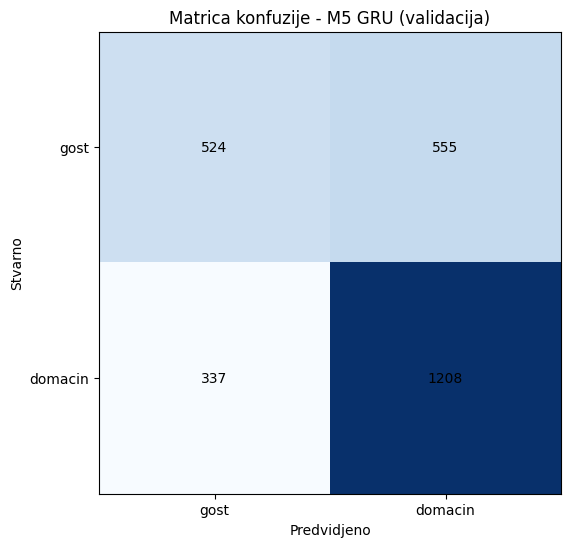

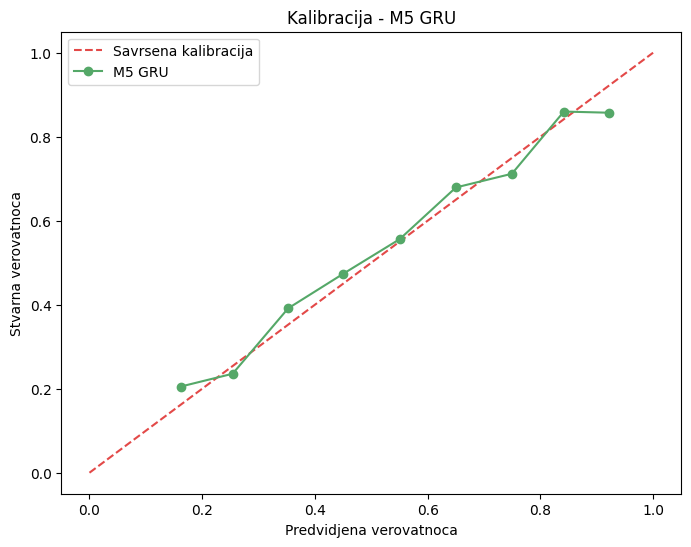

In [11]:
y_proba_val, y_true_val = train.predict_proba(model_gru, loader_val)
y_pred_val = (y_proba_val >= 0.5).astype(int)

evaluate.plot_confusion_matrix(y_true_val, y_pred_val, "Matrica konfuzije - M5 GRU (validacija)")
evaluate.plot_calibration_curve(y_true_val, y_proba_val, "M5 GRU")

Model mnogo bolje prepoznaje domaćine nego goste: odziv je 0.782 naspram 0.486. Pobedu domaćina najavljuje na oko 67% mečeva, iako domaćin pobeđuje u 58.9% - prag 0.5 nad neuravnoteženim klasama vuče predviđanja ka većoj klasi, pa je makro F1 (0.635) niži od tačnosti (0.660). Isti obrazac se vidi kod M3 i M4, ovde nešto blaži - odziv za goste (0.486) je bolji nego kod obe druge mreže.

Kalibracija prati isti obrazac kao kod RNN i LSTM - solidno uz dijagonalu u srednjem opsegu, sa blagom prekomernom samouverenošću na najvišim predviđenim verovatnoćama.

ROC-AUC, log-gubitak i Brier ostaju glavne metrike, jer ne zavise od praga: prag briše razliku između meča ocenjenog na 0.51 i onog na 0.95, a zadatak traži verovatnoću, ne odluku.

### Provera ivice mreže

Ako pobednik pretrage padne na najveću stopu učenja iz mreže (`0.003`), vredi proveriti šta leži izvan te granice — isti korak kao u sveskama 04-01 i 04-02. Svako podešavanje se meri prosekom po pet seedova, da razlika ne bude šum jednog pokretanja.

In [12]:
def oceni_stopu_ucenja(learning_rate, seeds=SEEDS):
    """Trenira M5 sa datom stopom ucenja, po jednom za svaki seed; vraca prosek i rasipanje."""
    prolazi_lr = train.train_over_seeds(
        dataset_train, dataset_val,
        n_features=home_train.shape[-1],
        n_context=context_train.shape[-1],
        cell="gru",
        hidden_size=int(najbolji["hidden_size"]),
        dropout=float(najbolji["dropout"]),
        learning_rate=learning_rate,
        seeds=seeds,
    )
    po_seedu = pd.DataFrame([p["metrike"] for p in prolazi_lr])
    return {
        "tacnost": po_seedu["tacnost"].mean(),
        "rasipanje": po_seedu["tacnost"].std(ddof=0),
        "roc_auc": po_seedu["roc_auc"].mean(),
    }

In [13]:
IVICA = (0.003, 0.006, 0.01, 0.02)

pd.DataFrame(
    [oceni_stopu_ucenja(lr) for lr in IVICA], index=[f"lr = {lr}" for lr in IVICA]
).round(4)

,tacnost,rasipanje,roc_auc
lr = 0.003,0.6579,0.0022,0.6975
lr = 0.006,0.6596,0.0011,0.6986
lr = 0.01,0.6590,0.0035,0.6975
lr = 0.02,0.6546,0.0046,0.6932


Optimum leži nešto izvan mreže, ali plitko - isti obrazac kao kod M4. Vrednost `0.006` daje ROC-AUC 0.6986 naspram 0.6975 za izabranu `0.003`, dobitak od 0.0011, manji od rasipanja na izabranoj vrednosti (0.0022). Iznad `0.01` se kvari: rasipanje raste na 0.0035, a na `0.02` ROC-AUC pada na 0.6932 uz rasipanje 0.0046.

Zanimljivo, `0.006` ima i manje rasipanje (0.0011) od izabrane `0.003` (0.0022) - stabilniji rezultat iz pokretanja u pokretanje. Razlika je ipak preplitka da opravda izlazak iz dogovorene mreže vrednosti, pa `learning_rate=0.003` ostaje izbor.

## Čuvanje modela

Čuva se stanje sa najmanjim validacionim gubitkom, jer `train_model` vraća model sa učitanim najboljim težinama.

Snima se svih pet prolaza, ne samo reprezentativni, jer je prijavljena metrika prosek po seedovima.

In [14]:
for prolaz in prolazi:
    train.save_model(prolaz["model"], f"gru_seed{prolaz['seed']}.pt")

sorted(p.name for p in MODELS_PATH.glob("gru_seed*.pt"))

['gru_seed17.pt',
 'gru_seed27.pt',
 'gru_seed37.pt',
 'gru_seed47.pt',
 'gru_seed7.pt']

## Zaključak

M5 (GRU) daje **65.8% tačnosti na validaciji (0.6579 ± 0.0022)**, uz ROC-AUC 0.698 (0.6975 ± 0.0013), log-gubitak 0.617 i Brier 0.214. Dvostepena pretraga bira `hidden_size=32`, `dropout=0.30` i `learning_rate=0.003`.

Prijavljena vrednost je prosek po pet seedova. Pojedinačni prolazi idu od 0.6555 do 0.6608, a za grafike, matricu konfuzije i kalibraciju služi prolaz sa seedom `RANDOM_STATE`.

Rezultat je praktično **identičan M1 logističkoj regresiji** (0.6563), **M3 RNN** (0.6579 - ista vrednost do četvrte decimale) i **M4 LSTM** (0.6566). Kapije GRU-a ne donose merljivu prednost nad običnom RNN na ovom skupu, u skladu sa očekivanjem iz plana: snaga tima se unutar sezone menja sporo, pa pokretni prosek i Elo već hvataju skoro sav dostupan signal - dodatni kapacitet arhitekture nema šta da iskoristi. Ablacija u svesci 04-02 to pokazuje direktno za M4, a isti mehanizam važi i ovde.

Izbor hiperparametara nije oštar, i drugi korak pretrage je ovde uradio više posla nego kod M3/M4: promenio je poredak, ne samo ga potvrdio - pobednik grube pretrage (`hidden_size=64`) pada na treće mesto kad se izmeri sa pet seedova, a `hidden_size=32` preskače sa trećeg na prvo. Svih pet finalista ipak staje u 0.0007 ROC-AUC. Provera ivice mreže pokazuje da bi `learning_rate=0.006` dao neznatno bolji i stabilniji rezultat, ali razlika je manja od rasipanja, pa `0.003` ostaje izbor.

Rano zaustavljanje preseca trening između 3. i 9. epohe, zavisno od seeda. Model je asimetričan zbog neravnoteže klasa: odziv 0.782 za domaćine i 0.486 za goste (reprezentativni prolaz), pobeda domaćina se najavljuje na oko 67% mečeva. Razmak trening-validacija je umeren (67.4% naspram 65.8%).

Prelaz sa jednog na pet seedova **nije promenio zaključak** - ranija procena sa jednim seedom i tri potvrde (0.698) je unutar rasipanja novog proseka (0.6975 ± 0.0013). Ali samo rasipanje je pouka, kao i kod M3 i M4: razlike od par desetinki procentnog poena između M1, M3, M4 i M5 su šum, ne poredak arhitektura - GRU sada deli identičnu tačnost sa RNN do četvrte decimale, čisto slučajno.

Modeli su sačuvani u `models/gru_seed7.pt` … `models/gru_seed47.pt`, a pojedinačni prolazi po seedu u `reports/rasipanje-semena.csv`. Sve tri rekurentne arhitekture (RNN, LSTM, GRU) su sada istrenirane sa dvostepenom pretragom i po pet seedova.